In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [33]:
df = pd.read_csv(r"C:\Users\NINAD\Downloads\bmw_50k_dataset (1).csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (55000, 15)


,brand,model,variant,year,price,fuel_type,transmission,engine_cc,mileage,power_bhp,torque_nm,drivetrain,body_type,kms_driven,ownership
0,BMW,M5,xLine,2026,124.85,Diesel,Manual,1953,13.92,421,486,AWD,Sedan,17588,1st
1,BMW,M8,Luxury Line,2021,84.64,Diesel,Manual,4838,20.12,525,460,RWD,Coupe,82862,1st
2,BMW,4 Series,Luxury Line,2011,31.33,Petrol,Automatic,2281,21.31,552,425,RWD,Coupe,188448,1st
3,BMW,M3,Sport,2024,157.66,Electric,Manual,0,7.39,492,580,AWD,Sedan,23160,1st
4,BMW,X2,Luxury Line,2025,30.82,Diesel,Manual,1895,12.06,507,242,AWD,SUV,114739,1st


In [3]:
features = ['model', 'year', 'kms_driven', 'fuel_type', 'transmission']
target = 'price'

X = df[features]
y = df[target]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
categorical_cols = ['model', 'fuel_type', 'transmission']
numerical_cols = ['year', 'kms_driven']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

In [6]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])


In [7]:
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [10]:
print("\n📊 Linear Regression Results")
print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))

print("\n🌲 Random Forest Results")
print("R2 Score:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))


📊 Linear Regression Results
R2 Score: 1.7562734896392485e-06
MAE: 48.77539003697224

🌲 Random Forest Results
R2 Score: -0.10005448785614135
MAE: 50.45055910757576


In [12]:
sample = pd.DataFrame({
    'model': ['X5'],
    'year': [2020],
    'kms_driven': [40000],
    'fuel_type': ['Diesel'],
    'transmission': ['Automatic']
})
pred_price = rf_model.predict(sample)
print("\n💰 Predicted Price:", pred_price[0], "Lakhs")


💰 Predicted Price: 112.65340000000003 Lakhs


In [13]:
def recommend_car(budget, df):
    filtered = df[df['price'] <= budget]
    if filtered.empty:
        return "No cars found under this budget"
    
    best = filtered.sort_values(by='price', ascending=False).head(5)
    return best[['model', 'price', 'year']]

print("\n🚗 Recommended Cars under 50 Lakhs:")
print(recommend_car(50, df))



🚗 Recommended Cars under 50 Lakhs:
          model  price  year
3641   1 Series  50.00  2005
42974        i3  50.00  2001
18005  8 Series  50.00  2009
37259  8 Series  50.00  2008
50278        M8  49.99  2025


In [14]:
features = ['model', 'year', 'kms_driven', 'fuel_type', 'transmission',
            'engine_cc', 'power_bhp']

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
plt.rcParams['figure.figsize'] = (10, 6)

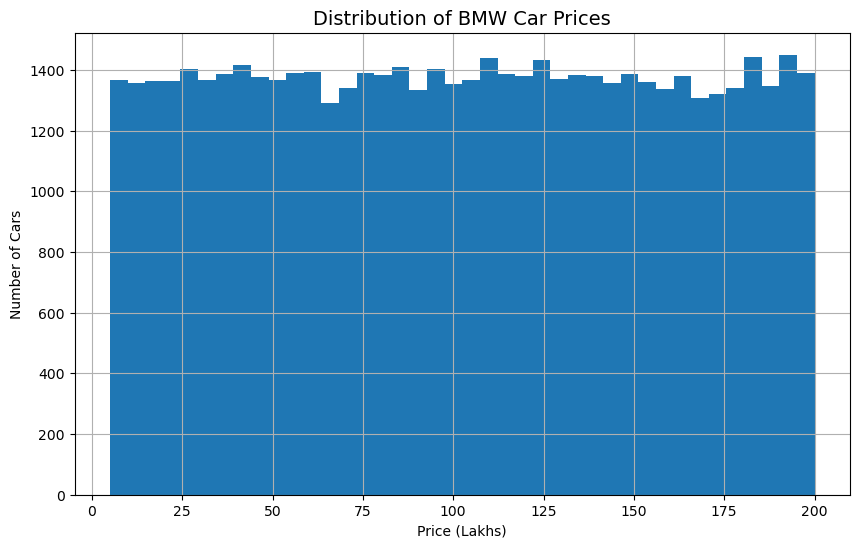

In [17]:
plt.hist(df['price'], bins=40)
plt.title("Distribution of BMW Car Prices", fontsize=14)
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Cars")
plt.grid(True)
plt.show()

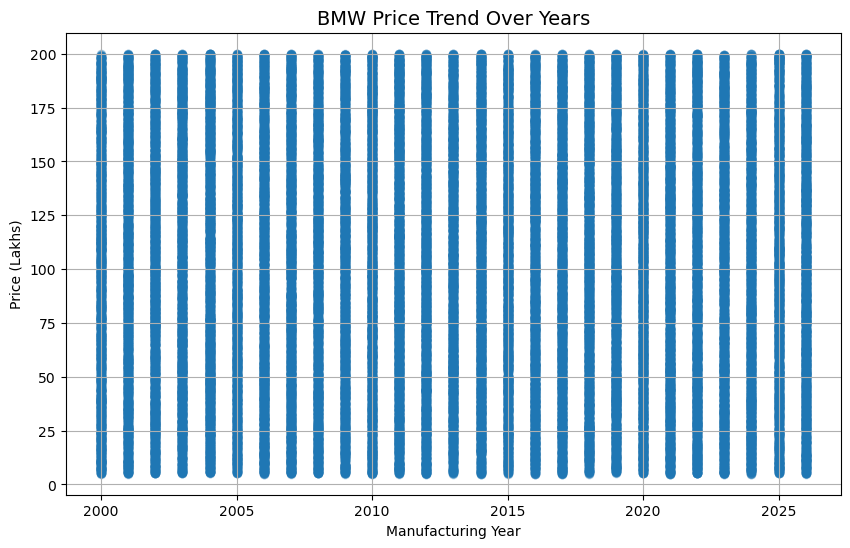

In [18]:
plt.scatter(df['year'], df['price'], alpha=0.3)
plt.title("BMW Price Trend Over Years", fontsize=14)
plt.xlabel("Manufacturing Year")
plt.ylabel("Price (Lakhs)")
plt.grid(True)
plt.show()

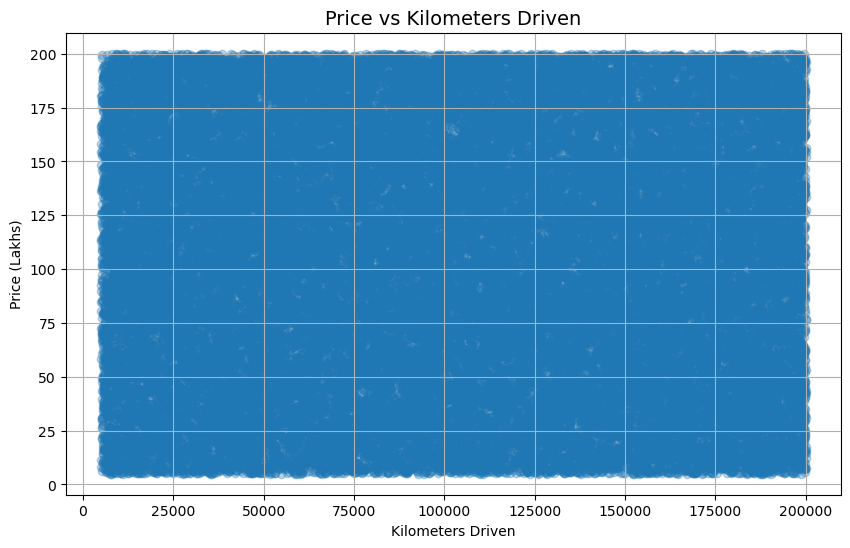

In [19]:
plt.scatter(df['kms_driven'], df['price'], alpha=0.3)
plt.title("Price vs Kilometers Driven", fontsize=14)
plt.xlabel("Kilometers Driven")
plt.ylabel("Price (Lakhs)")
plt.grid(True)
plt.show()


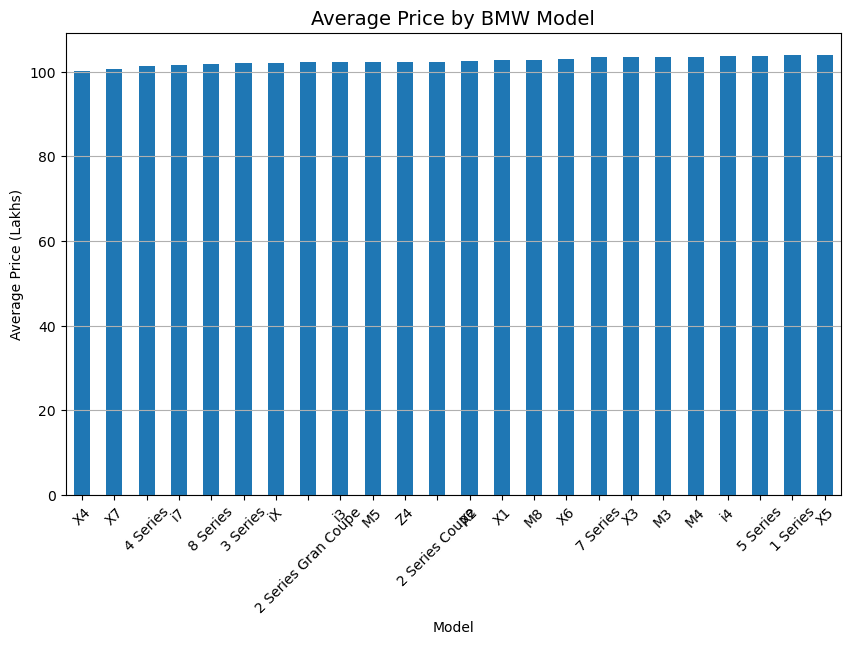

In [20]:
avg_price_model = df.groupby('model')['price'].mean().sort_values()

avg_price_model.plot(kind='bar')
plt.title("Average Price by BMW Model", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


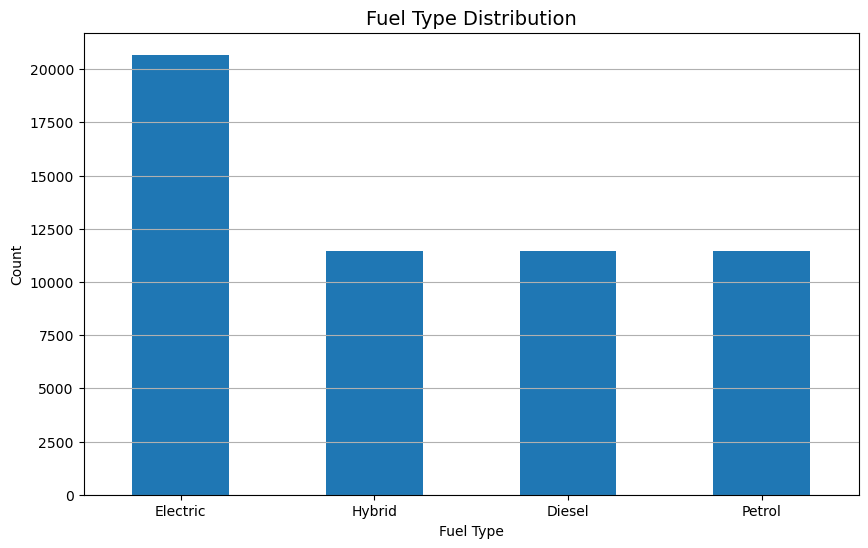

In [21]:
df['fuel_type'].value_counts().plot(kind='bar')
plt.title("Fuel Type Distribution", fontsize=14)
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


In [22]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Random Search
random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    verbose=2,
    n_jobs=-1
)

# Train
random_search.fit(X_train, y_train)

# Best Model
best_model = random_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error

print("🔥 Optimized Model Results")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
🔥 Optimized Model Results
R2 Score: -0.0018949550404019355
MAE: 48.824305946493276


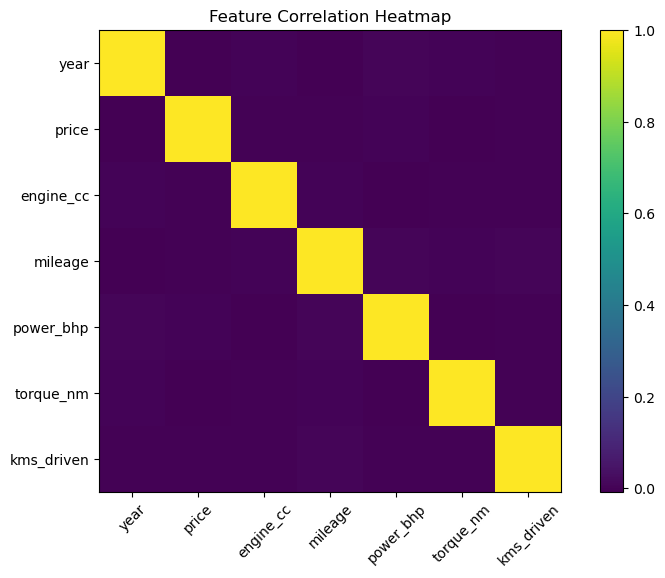

In [23]:
import matplotlib.pyplot as plt
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Heatmap")
plt.show()

In [24]:
print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Optimized Model R2:", r2_score(y_test, y_pred))

Linear Regression R2: 1.7562734896392485e-06
Random Forest R2: -0.10005448785614135
Optimized Model R2: -0.0018949550404019355
